C:\Users\lenovo\AppData\Local\Temp\ipykernel_18148\3856138452.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Removed 103 duplicate rows. New shape: (285, 13)

--- Target Variable Distribution (Output) ---
Output
Yes    76.140351
No     23.859649
Name: proportion, dtype: float64

--- Statistical Association with 'Output' ---
Gender                    | Chi2:    0.21 | p-value: 0.64677 | Cramer's V: 0.027 | Sparse Cells: 0.0%
Marital Status            | Chi2:   23.62 | p-value: 0.00001 | Cramer's V: 0.288 | Sparse Cells: 16.7%
Occupation                | Chi2:   21.61 | p-value: 0.00008 | Cramer's V: 0.275 | Sparse Cells: 12.5%
Monthly Income            | Chi2:   14.94 | p-value: 0.00482 | Cramer's V: 0.229 | Sparse Cells: 10.0%
Educational Qualifications | Chi2:    7.52 | p-value: 0.11099 | Cramer's V: 0.162 | Sparse Cells: 30.0%
Customer Type             | Chi2:    0.29 | p-value: 0.86417 | Cramer's V: 0.032 | Sparse Cells: 16.7%
Feedback                  | Chi2:   82.52 | p-value: 0.00000 | Cramer's V: 0.538 | Sparse Cells: 0.0%


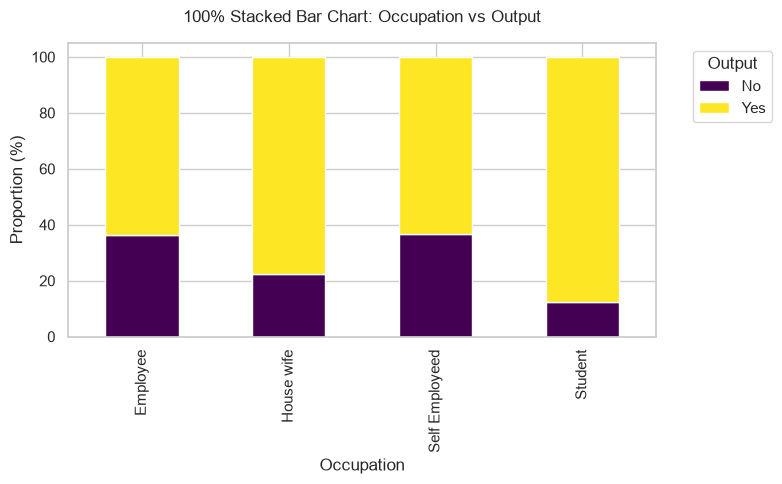

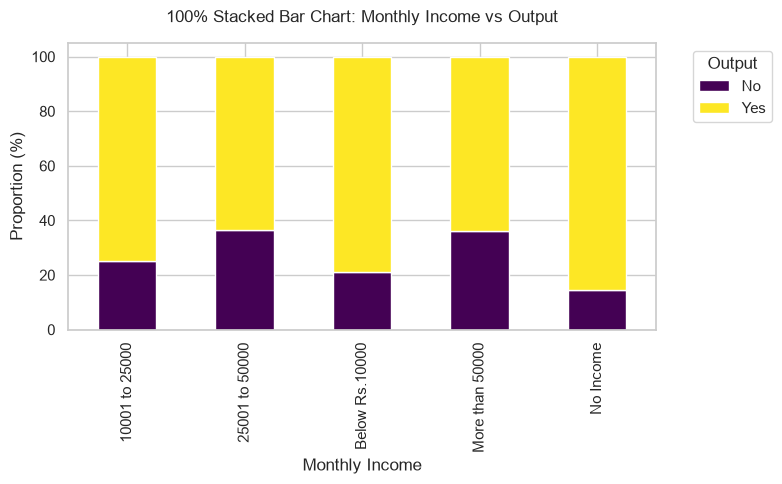

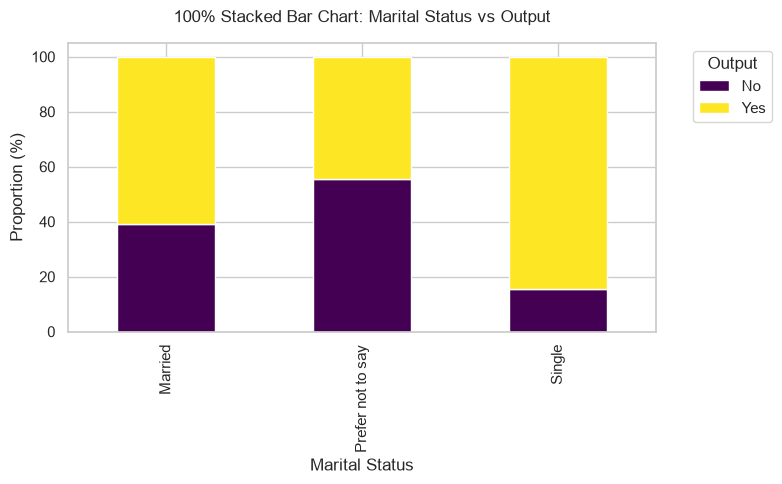


--- Generating Geospatial Clusters via Haversine DBSCAN ---
Cluster Distributions (Note: '-1' indicates spatial noise/outliers):
Geo_Cluster
0     164
-1     49
1      23
2       8
3       7
7       7
4       6
5       6
6       5
8       5
9       5
Name: count, dtype: int64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.cluster import DBSCAN

# Set visualization style
sns.set_theme(style="whitegrid")

# ==========================================
# PHASE 1: Data Ingestion & Structural Integrity
# ==========================================
# Load the dataset
df = pd.read_csv("C:\\Users\\lenovo\\OneDrive\\Desktop\\mlops_2\\data\\data.csv")

# 1. Eradicate Multicollinearity & Data Leakage 
if 'Unnamed: 13' in df.columns:
    df = df.drop(columns=['Unnamed: 13'])

# 2. String Cleaning (Removing trailing whitespaces from categorical features like 'Feedback')
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

# 3. Datatype Override: Force Pin code to behave as a nominal string, not an integer
if 'Pin code' in df.columns:
    df['Pin code'] = df['Pin code'].astype(str)

# 4. Redundancy Removal (Drop identical observations to prevent training bias)
initial_shape = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {initial_shape - df.shape[0]} duplicate rows. New shape: {df.shape}")

# ==========================================
# PHASE 2: Target Variable Diagnostics
# ==========================================
print("\n--- Target Variable Distribution (Output) ---")
print(df['Output'].value_counts(normalize=True) * 100)

# ==========================================
# PHASE 3: Bivariate Statistical Association
# ==========================================
def calculate_cramers_v(crosstab):
    """Calculates Cramér's V for a given cross-tabulation array."""
    chi2 = chi2_contingency(crosstab)[0]
    n = crosstab.sum().sum()
    r, k = crosstab.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

features_to_test = ['Gender', 'Marital Status', 'Occupation', 'Monthly Income', 
                    'Educational Qualifications', 'Customer Type', 'Feedback']

print("\n--- Statistical Association with 'Output' ---")
for col in features_to_test:
    if col in df.columns:
        ct = pd.crosstab(df[col], df['Output'])
        chi2, p_val, dof, expected = chi2_contingency(ct)
        v = calculate_cramers_v(ct)
        # Check sparsity assumption (cells with expected counts < 5)
        sparsity = (expected < 5).sum() / expected.size * 100
        
        print(f"{col:25} | Chi2: {chi2:>7.2f} | p-value: {p_val:>7.5f} | Cramer's V: {v:>5.3f} | Sparse Cells: {sparsity:.1f}%")

# ==========================================
# PHASE 4: Multi-dimensional Demographic Cross-Tabulation
# ==========================================
# Generate 100% stacked bar charts for high-signal socioeconomic markers
high_signal_features = ['Occupation', 'Monthly Income', 'Marital Status']

for feature in high_signal_features:
    if feature in df.columns:
        # Normalize index to 100% for proportional comparison
        ct_norm = pd.crosstab(df[feature], df['Output'], normalize='index') * 100
        
        ct_norm.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='viridis')
        plt.title(f'100% Stacked Bar Chart: {feature} vs Output', pad=15)
        plt.ylabel('Proportion (%)')
        plt.xlabel(feature)
        plt.legend(title='Output', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# ==========================================
# PHASE 5: Geospatial Feature Engineering
# ==========================================
if 'latitude' in df.columns and 'longitude' in df.columns:
    print("\n--- Generating Geospatial Clusters via Haversine DBSCAN ---")
    
    # The Haversine metric requires coordinates to be in radians
    coords = np.radians(df[['latitude', 'longitude']])
    
    # Define physical distance for clustering (e.g., 2 kilometers)
    kms_per_radian = 6371.0088
    epsilon = 2.0 / kms_per_radian
    
    # Execute Density-Based Spatial Clustering with Noise
    dbscan = DBSCAN(eps=epsilon, min_samples=5, algorithm='ball_tree', metric='haversine')
    df['Geo_Cluster'] = dbscan.fit_predict(coords)
    df['Geo_Cluster'] = df['Geo_Cluster'].astype(str) # Treat clusters as categories
    
    print("Cluster Distributions (Note: '-1' indicates spatial noise/outliers):")
    print(df['Geo_Cluster'].value_counts())

In [4]:
df.head()
df.info()

<class 'pandas.DataFrame'>
Index: 285 entries, 0 to 386
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         285 non-null    int64  
 1   Gender                      285 non-null    str    
 2   Marital Status              285 non-null    str    
 3   Occupation                  285 non-null    str    
 4   Monthly Income              285 non-null    str    
 5   Educational Qualifications  285 non-null    str    
 6   Family size                 285 non-null    int64  
 7   Customer Type               285 non-null    str    
 8   latitude                    285 non-null    float64
 9   longitude                   285 non-null    float64
 10  Pin code                    285 non-null    str    
 11  Output                      285 non-null    str    
 12  Feedback                    285 non-null    str    
 13  Geo_Cluster                 285 non-null    str    

C:\Users\lenovo\AppData\Local\Temp\ipykernel_18148\997752977.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Output', palette='Set2')


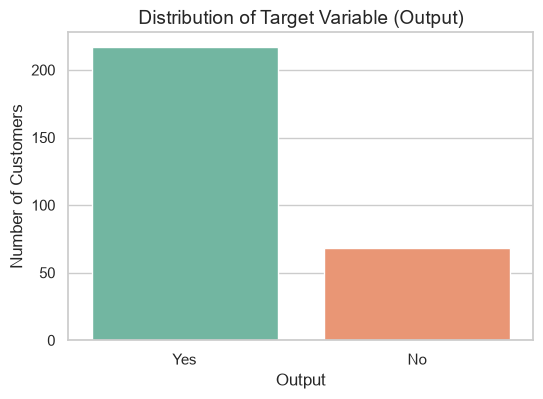

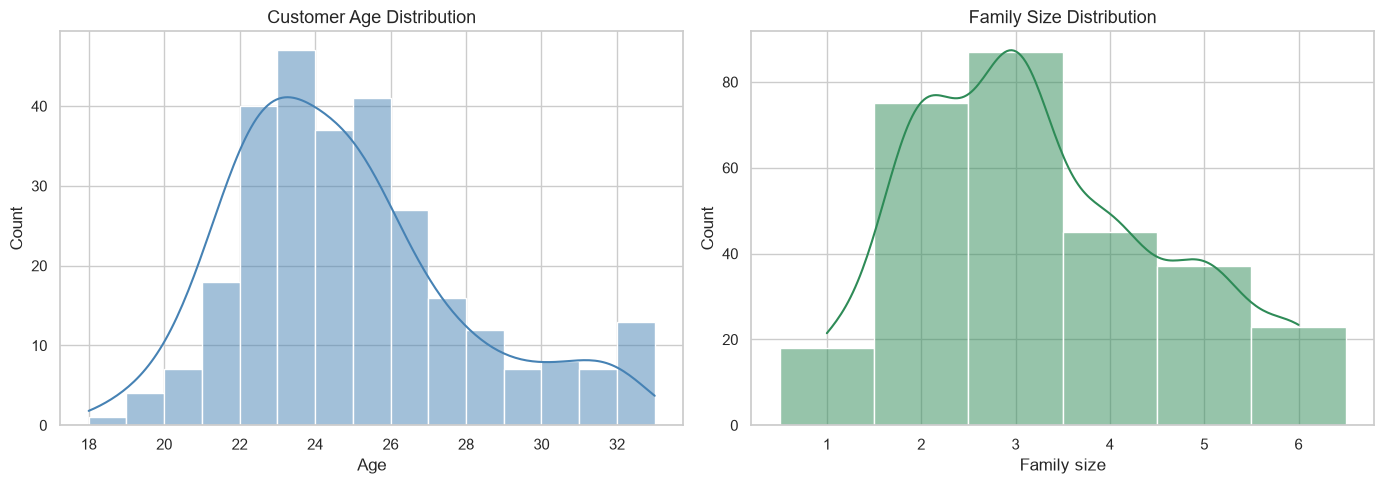

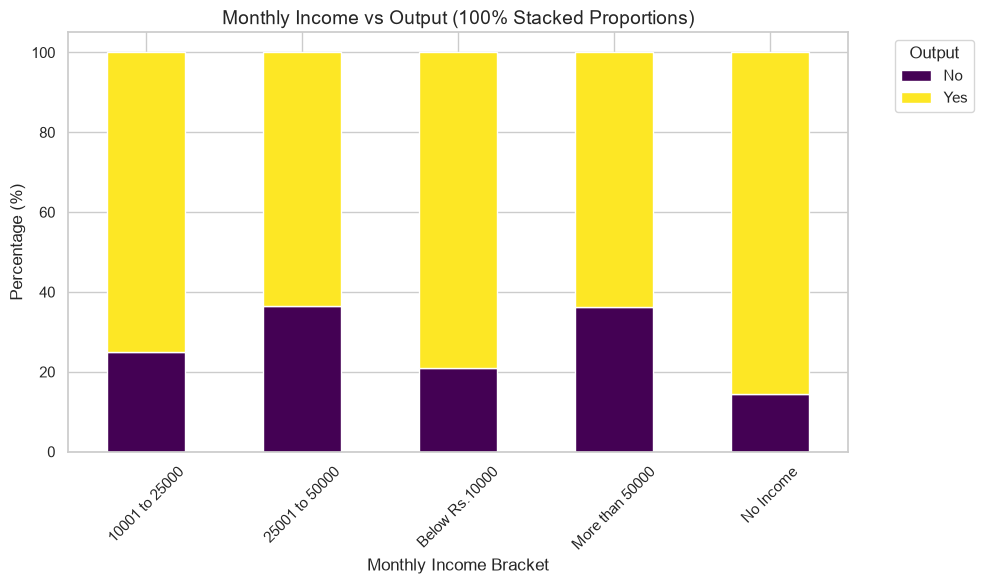

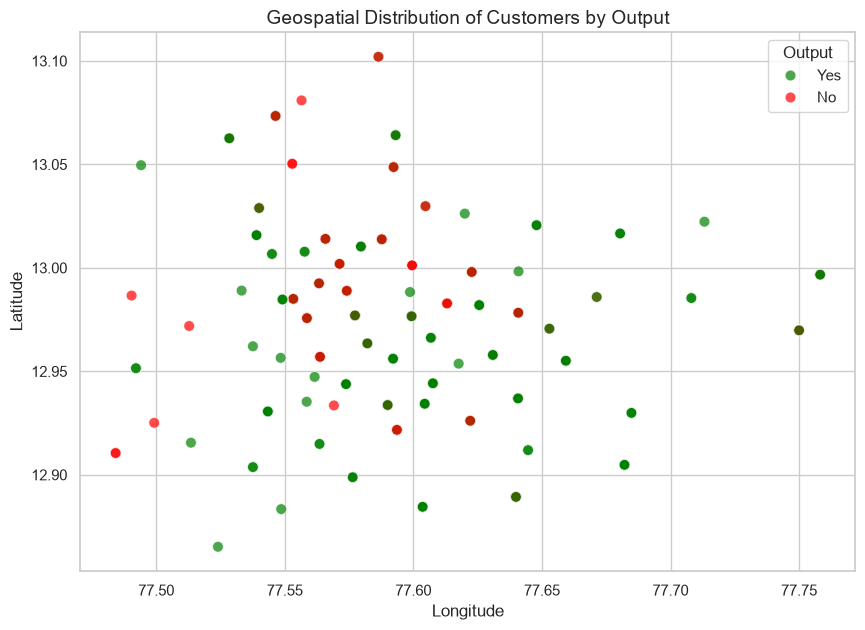

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizations ke liye clear aur professional theme set karna
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Graph 1: Target Variable (Output) ka Class Imbalance Check
# ---------------------------------------------------------
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Output', palette='Set2')
plt.title('Distribution of Target Variable (Output)', fontsize=14)
plt.ylabel('Number of Customers')
plt.xlabel('Output')
plt.show()

# ---------------------------------------------------------
# Graph 2: Numeric Variables (Age aur Family size) ka Distribution
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution with KDE (Kernel Density Estimate)
sns.histplot(df['Age'], kde=True, ax=axes[0], color='steelblue', bins=15)
axes[0].set_title('Customer Age Distribution', fontsize=13)

# Family size distribution
sns.histplot(df['Family size'], kde=True, ax=axes[1], color='seagreen', discrete=True)
axes[1].set_title('Family Size Distribution', fontsize=13)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Graph 3: 100% Stacked Bar Chart (Monthly Income vs Output)
# ---------------------------------------------------------
# Is graph se pata chalega ki kis income group mein positive output ka percentage zyada hai
if 'Monthly Income' in df.columns:
    income_cross = pd.crosstab(df['Monthly Income'], df['Output'], normalize='index') * 100
    
    income_cross.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
    plt.title('Monthly Income vs Output (100% Stacked Proportions)', fontsize=14)
    plt.ylabel('Percentage (%)')
    plt.xlabel('Monthly Income Bracket')
    plt.xticks(rotation=45)
    plt.legend(title='Output', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Graph 4: Geospatial Scatter Plot (Latitude vs Longitude)
# ---------------------------------------------------------
# Ye map customers ki physical location ko 'Output' ke hisaab se color-code karega
if 'latitude' in df.columns and 'longitude' in df.columns:
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=df, 
        x='longitude', 
        y='latitude', 
        hue='Output', 
        palette={'Yes': 'green', 'No': 'red'}, 
        alpha=0.7, 
        s=60
    )
    plt.title('Geospatial Distribution of Customers by Output', fontsize=14)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend(title='Output', loc='best')
    plt.show()